# Portfolio Analysis — Equally-Weighted (Equity, Fixed Income, Commodity)

This notebook loads three Excel files (**Equity.xlsx**, **Fixed Income.xlsx**, **Commodity.xlsx**) that each contain **Date** and **Close Price**.
It computes:
- Daily Returns (assets)
- Portfolio Daily Return (equal-weight)
- Annualized Volatility (×√252)
- Sharpe Ratio (rf = 1%)
- Correlation Matrix

It also **exports**:
- CSVs for KPIs and supporting tables
- PNG charts for cumulative return, correlation heatmap, and rolling 90-day volatility


In [1]:
import os
# Force headless, must be set before importing pyplot
os.environ["MPLBACKEND"] = "Agg"

import matplotlib
matplotlib.use("Agg", force=True)  # ensure non-GUI backend

import matplotlib.pyplot as plt

%pip install -q --upgrade "matplotlib==3.7.3" "matplotlib-inline==0.1.6" ipykernel


# %pip install --quiet pandas matplotlib openpyxl
import os
import pandas as pd
import numpy as np


EQUITY_PATH = "./Equity.xlsx"
FIXED_PATH  = "./Fixed Income.xlsx"
CMDTY_PATH  = "./Commodity.xlsx"
OUT_DIR     = "./Portfolio Analysis"
os.makedirs(OUT_DIR, exist_ok=True)



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: C:\Users\Priyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 1) drops first rows/col, finds embedded header

In [2]:

def read_price_embedded(path, label):
    df = pd.read_excel(path, header=None, dtype=str)
    # drop fully empty columns first
    df = df.dropna(axis=1, how="all")

    # remove the first 3 rows (often blank/title rows)
    df = df.iloc[3:].reset_index(drop=True)

    # remove first column if it's empty
    if df.shape[1] > 0:
        first = df.iloc[:, 0].astype(str)
        if first.str.strip().replace("nan","").eq("").all():
            df = df.iloc[:, 1:].copy()

    # locate header row containing 'date' and 'close price'
    header_idx = None; date_col=None; price_col=None
    for i in range(len(df)):
        row = df.iloc[i].astype(str).str.strip().str.lower().tolist()
        di = [j for j,v in enumerate(row) if v == "date" or "date" in v]
        pi = [j for j,v in enumerate(row) if ("close" in v and "price" in v) or v == "close price"]
        if di and pi:
            header_idx = i; date_col = di[0]; price_col = pi[0]; break
    if header_idx is None:
        raise ValueError(f"[{label}] Could not find 'Date' and 'Close Price' header row in {os.path.basename(path)}")

    sub = df.iloc[header_idx+1:, [date_col, price_col]].copy()
    sub.columns = ["Date","Close"]
    sub["Date"]  = pd.to_datetime(sub["Date"], errors="coerce")
    sub["Close"] = pd.to_numeric(sub["Close"].astype(str).str.replace(",",""), errors="coerce")
    sub = sub.dropna(subset=["Date","Close"]).sort_values("Date").set_index("Date")
    return sub["Close"].rename(label)

p_eq  = read_price_embedded(EQUITY_PATH, "Equity")
p_fi  = read_price_embedded(FIXED_PATH,  "FixedIncome")
p_cmd = read_price_embedded(CMDTY_PATH,  "Commodity")

prices = pd.concat([p_eq, p_fi, p_cmd], axis=1, join="inner").dropna()
prices.head()


,Equity,FixedIncome,Commodity
Date,,,
2019-12-31,3230.78,22.72,142.90
2020-01-02,3257.85,22.76,143.95
2020-01-03,3234.85,22.88,145.86
2020-01-06,3246.28,22.85,147.39
2020-01-07,3237.18,22.80,147.97


## 2) Returns, equal‑weight portfolio, metrics

In [13]:

rets = prices.pct_change().dropna()
assets  = ["Equity","FixedIncome","Commodity"]
weights = np.array([1/3,1/3,1/3])

r_pf = (rets[assets] @ weights).rename("Portfolio")

def ann_return(r):
    T = r.shape[0]
    return (1 + r).prod()**(252/T) - 1

def ann_vol(r):
    return r.std(ddof=0) * (252**0.5)

RF = 0.01
def sharpe(r):
    vol = ann_vol(r)
    return np.nan if vol == 0 else (ann_return(r) - RF) / vol

portfolio_ann_ret = ann_return(r_pf)
portfolio_ann_vol = ann_vol(r_pf)
portfolio_sharpe  = sharpe(r_pf)

corr_matrix = rets[assets].corr().round(3)

kpis = pd.DataFrame({
    "Metric": ["Annualized Return", "Annualized Volatility", "Sharpe (rf=1%)"],
    "Portfolio": [portfolio_ann_ret, portfolio_ann_vol, portfolio_sharpe]
}).round(6)
kpis


,Metric,Portfolio
0,Annualized Return,0.109889
1,Annualized Volatility,0.097628
2,Sharpe (rf=1%),1.023157


## 3) Charts (display + save PNGs)

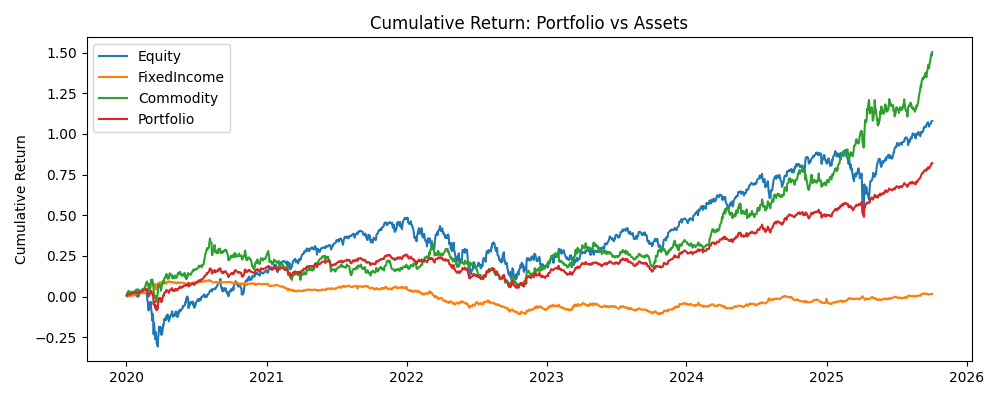

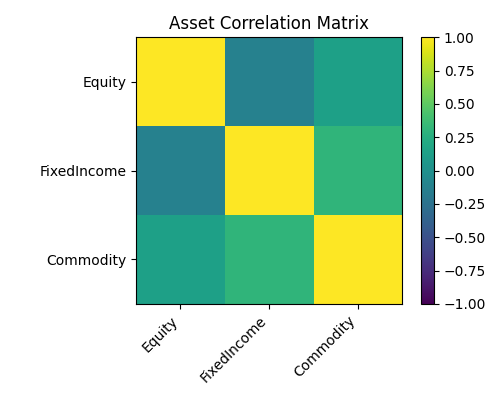

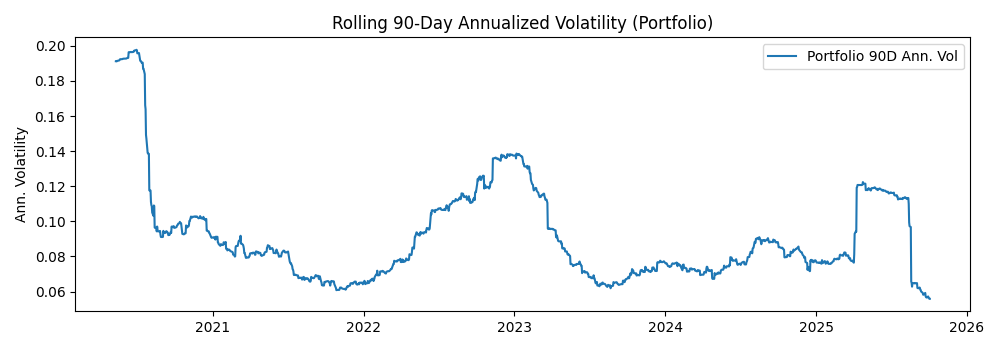

Saved charts to: d:\central bank interview\Portfolio_Analysis\Portfolio Analysis


In [14]:
import os
from pathlib import Path
import matplotlib
matplotlib.use("Agg")  # safe, headless backend for VS Code
import matplotlib.pyplot as plt
from IPython.display import Image, display
import numpy as np

# 0) Ensure we have the inputs computed earlier:
#    `rets` must be a DataFrame with ['Equity','FixedIncome','Commodity']
#    `r_pf` must be the portfolio daily returns Series (equal-weight)
required_cols = ["Equity", "FixedIncome", "Commodity"]
if "rets" not in globals():
    raise NameError("`rets` is not defined. Run the cell that computes daily returns first.")
missing = [c for c in required_cols if c not in rets.columns]
if missing:
    raise ValueError(f"Missing columns in `rets`: {missing}. Re-run your returns cell.")

# 1) Create the output folder (this fixes FileNotFoundError)
OUT_DIR = Path.cwd() / "Portfolio Analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 2) Clean & align data
rets_clean = rets[required_cols].dropna(how="any")
if rets_clean.empty:
    raise ValueError("No overlapping rows after dropna in `rets`. Check your input series dates.")

# Build portfolio if missing
if "r_pf" not in globals():
    w = np.array([1/3, 1/3, 1/3])
    r_pf = (rets_clean @ w).rename("Portfolio")
else:
    # align to the asset window
    r_pf = r_pf.reindex(rets_clean.index).dropna()

# 3) Recompute cumulative series
cum_eq  = (1 + rets_clean["Equity"]).cumprod() - 1
cum_fi  = (1 + rets_clean["FixedIncome"]).cumprod() - 1
cum_cmd = (1 + rets_clean["Commodity"]).cumprod() - 1
cum_pf  = (1 + r_pf).cumprod() - 1

# ---------- (A) Cumulative Return ----------
plt.figure(figsize=(10,4))
plotted = 0
for series, label in [(cum_eq,"Equity"), (cum_fi,"FixedIncome"), (cum_cmd,"Commodity"), (cum_pf,"Portfolio")]:
    if series.notna().any():
        plt.plot(series.index, series.values, label=label); plotted += 1
plt.title("Cumulative Return: Portfolio vs Assets")
plt.ylabel("Cumulative Return")
if plotted:
    plt.legend()
plt.tight_layout()
out_path = OUT_DIR / "cumulative_return.png"
plt.savefig(str(out_path))
plt.close()
display(Image(filename=str(out_path)))

# ---------- (B) Correlation Heatmap ----------
corr_matrix = rets_clean.corr()
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix))); ax.set_yticks(range(len(corr_matrix)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)
plt.colorbar(im, ax=ax)
plt.title("Asset Correlation Matrix")
plt.tight_layout()
out_path = OUT_DIR / "correlation_heatmap.png"
fig.savefig(str(out_path))
plt.close(fig)
display(Image(filename=str(out_path)))

# ---------- (C) Rolling 90-day Annualized Volatility ----------
roll90 = r_pf.rolling(90).std() * (252 ** 0.5)
plt.figure(figsize=(10,3.5))
if roll90.notna().any():
    plt.plot(roll90.index, roll90.values, label="Portfolio 90D Ann. Vol")
    plt.legend()
plt.title("Rolling 90-Day Annualized Volatility (Portfolio)")
plt.ylabel("Ann. Volatility")
plt.tight_layout()
out_path = OUT_DIR / "rolling_volatility_90d.png"
plt.savefig(str(out_path))
plt.close()
display(Image(filename=str(out_path)))

print("Saved charts to:", OUT_DIR)

## 4) Export CSVs for dashboarding

In [15]:

# Tables
rets[assets].to_csv(f"{OUT_DIR}/daily_returns_assets.csv")
r_pf.to_csv(f"{OUT_DIR}/portfolio_returns.csv")
pd.DataFrame({
    "Portfolio": (1 + r_pf).cumprod() - 1,
    "Equity":    (1 + rets["Equity"]).cumprod() - 1,
    "FixedIncome": (1 + rets["FixedIncome"]).cumprod() - 1,
    "Commodity": (1 + rets["Commodity"]).cumprod() - 1,
}).to_csv(f"{OUT_DIR}/cumulative_curves.csv")
corr_matrix.to_csv(f"{OUT_DIR}/correlation_matrix.csv")
( r_pf.rolling(90).std() * (252**0.5) ).to_csv(f"{OUT_DIR}/rolling_vol_90.csv")
kpis.to_csv(f"{OUT_DIR}/kpis.csv", index=False)

print("Saved outputs to:", OUT_DIR)


Saved outputs to: d:\central bank interview\Portfolio_Analysis\Portfolio Analysis
